# Model Evaluation Basics: Accuracy and Confusion Matrix

This notebook introduces fundamental model evaluation techniques for classification problems, focusing on accuracy metrics and confusion matrices.

## 1. Import Required Libraries

We'll need the following libraries for model training and evaluation:
- scikit-learn for machine learning algorithms and evaluation metrics
- numpy and pandas for data manipulation
- matplotlib and seaborn for visualization

In [1]:
# Import essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, 
                            precision_score, recall_score, f1_score,
                            roc_curve, roc_auc_score, precision_recall_curve)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# For reproducibility
np.random.seed(42)

## 2. Generate Sample Data

Let's load a real-world dataset for our classification tasks. We'll use the Breast Cancer Wisconsin dataset, which is a binary classification problem where the task is to classify tumors as malignant or benign based on various features.

In [2]:
# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Display basic information about the dataset
print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution:\n{pd.Series(y).value_counts()}")
print("\nFeature names:")
for i, feature in enumerate(data.feature_names):
    print(f"{i+1}. {feature}")

# Create a pandas DataFrame for better data exploration
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

# Display the first few rows
print("\nData sample:")
df.head()

Dataset shape: (569, 30)
Number of classes: 2
Class distribution:
1    357
0    212
Name: count, dtype: int64

Feature names:
1. mean radius
2. mean texture
3. mean perimeter
4. mean area
5. mean smoothness
6. mean compactness
7. mean concavity
8. mean concave points
9. mean symmetry
10. mean fractal dimension
11. radius error
12. texture error
13. perimeter error
14. area error
15. smoothness error
16. compactness error
17. concavity error
18. concave points error
19. symmetry error
20. fractal dimension error
21. worst radius
22. worst texture
23. worst perimeter
24. worst area
25. worst smoothness
26. worst compactness
27. worst concavity
28. worst concave points
29. worst symmetry
30. worst fractal dimension

Data sample:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


## 3. Train a Basic Classification Model

Now, let's split our data into training and testing sets, and train a simple logistic regression model.

In [5]:
# # Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# print(f"Training set shape: {X_train.shape}")
# print(f"Testing set shape: {X_test.shape}")

# # Train a logistic regression model
# log_reg = LogisticRegression(max_iter=1000, random_state=42)
# log_reg.fit(X_train, y_train)

# # Make predictions on the test set
# y_pred = log_reg.predict(X_test)

```
ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
```

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Create a pipeline with scaling and logistic regression
pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42)  # Increased max_iter
)

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions
y_pred = pipeline.predict(X_test)

Training set shape: (426, 30)
Testing set shape: (143, 30)


## 4. Calculate Accuracy

Accuracy is the most straightforward metric for evaluating classification models. It measures the proportion of correct predictions among the total number of predictions.

**Formula:**
$$\text{Accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of predictions}}$$

However, accuracy can be misleading when dealing with imbalanced datasets where one class is much more prevalent than others.

In [7]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Alternative way to calculate accuracy
accuracy_alt = np.mean(y_test == y_pred)
print(f"Accuracy (alternative calculation): {accuracy_alt:.4f}")

# Model's built-in score method (which is accuracy for classification)
model_score = log_reg.score(X_test, y_test)
print(f"Model score: {model_score:.4f}")

Accuracy: 0.9790
Accuracy (alternative calculation): 0.9790
Model score: 0.9650


### Strengths and Limitations of Accuracy

**Strengths:**
- Easy to understand and interpret
- Works well when classes are balanced
- Single metric to compare different models

**Limitations:**
- Can be misleading for imbalanced datasets
- Doesn't provide insight into types of errors
- Doesn't account for prediction probabilities, only final decisions

Let's examine a case where accuracy might be misleading by creating an imbalanced dataset:

In [8]:
# Create an imbalanced dataset
X_imb, y_imb = make_classification(
    n_samples=1000, n_features=20, n_informative=15, 
    n_redundant=5, weights=[0.95, 0.05], random_state=42
)

# Split into train and test
X_imb_train, X_imb_test, y_imb_train, y_imb_test = train_test_split(
    X_imb, y_imb, test_size=0.25, random_state=42
)

# Display class distribution
print("Class distribution in the imbalanced dataset:")
print(pd.Series(y_imb).value_counts())

# Train a naive model that always predicts the majority class
class MajorityClassifier:
    def fit(self, X, y):
        self.majority_class = np.bincount(y).argmax()
        return self
    
    def predict(self, X):
        return np.full(X.shape[0], self.majority_class)

naive_model = MajorityClassifier().fit(X_imb_train, y_imb_train)
y_imb_pred_naive = naive_model.predict(X_imb_test)

# Calculate accuracy of the naive model
naive_accuracy = accuracy_score(y_imb_test, y_imb_pred_naive)
print(f"\nAccuracy of naive majority class classifier: {naive_accuracy:.4f}")
print("Despite the high accuracy, this model doesn't provide any value as it always predicts the majority class!")

Class distribution in the imbalanced dataset:
0    947
1     53
Name: count, dtype: int64

Accuracy of naive majority class classifier: 0.9440
Despite the high accuracy, this model doesn't provide any value as it always predicts the majority class!


## 5. Create and Visualize Confusion Matrix

A confusion matrix provides a more detailed breakdown of predictions by showing:
- True Positives (TP): Correct positive predictions
- True Negatives (TN): Correct negative predictions
- False Positives (FP): Incorrect positive predictions (Type I error)
- False Negatives (FN): Incorrect negative predictions (Type II error)

Let's create and visualize a confusion matrix for our original model:

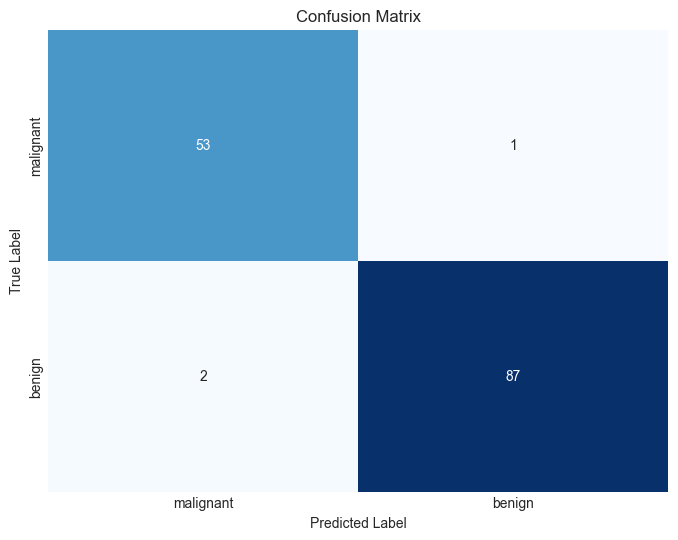

True Negatives (TN): 53
False Positives (FP): 1
False Negatives (FN): 2
True Positives (TP): 87


In [9]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Calculate and display values
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

## 6. Understanding Confusion Matrix Elements

Let's explore what each element of the confusion matrix means in the context of our breast cancer dataset:

- **True Positives (TP)**: Cases correctly predicted as benign (class 1)
- **True Negatives (TN)**: Cases correctly predicted as malignant (class 0)
- **False Positives (FP)**: Malignant tumors incorrectly classified as benign (Type I error)
- **False Negatives (FN)**: Benign tumors incorrectly classified as malignant (Type II error)

In this medical context:
- False Positives might lead to unnecessary treatments
- False Negatives might lead to missed treatments (potentially more serious)

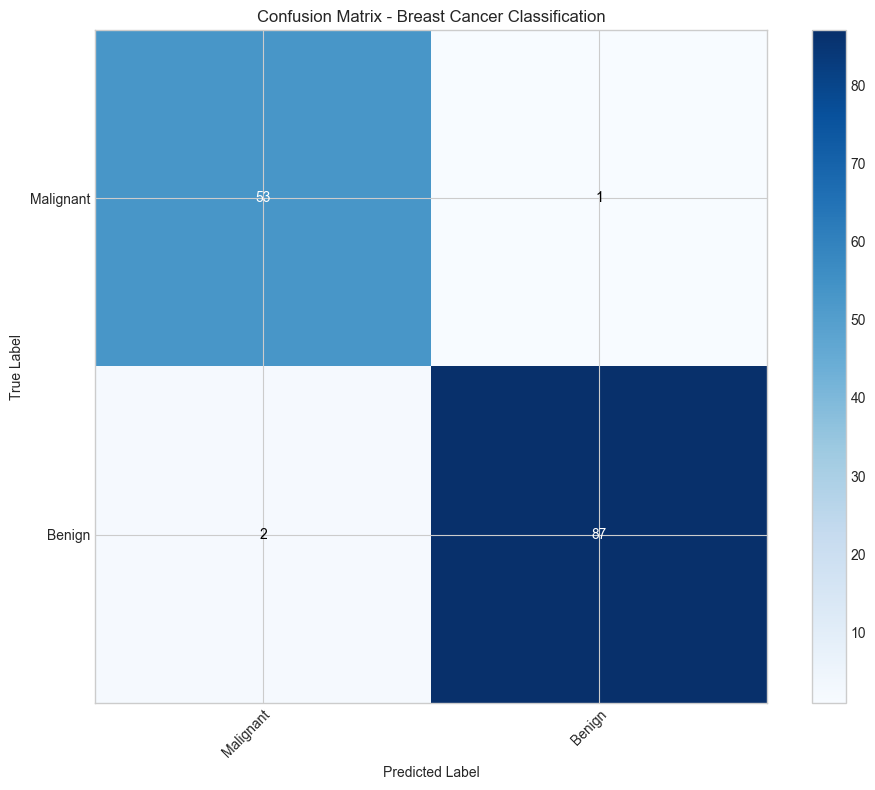

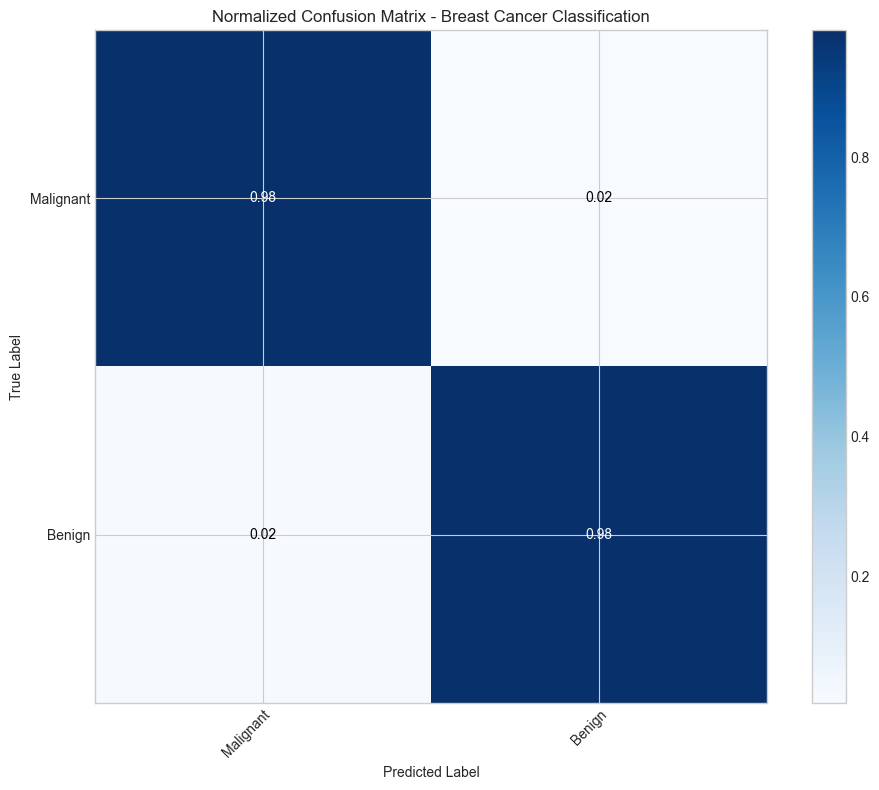

In [10]:
# Function to create a prettier confusion matrix with percentages
def plot_confusion_matrix(y_true, y_pred, classes, normalize=False, title=None, cmap=plt.cm.Blues):
    """
    Create a prettier confusion matrix plot with percentages.
    """
    if not title:
        if normalize:
            title = 'Normalized Confusion Matrix'
        else:
            title = 'Confusion Matrix'
    
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True Label',
           xlabel='Predicted Label')
    
    # Rotate the tick labels and set alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Loop over data dimensions and create text annotations
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax

# Create enhanced confusion matrix visualization
plot_confusion_matrix(y_test, y_pred, classes=['Malignant', 'Benign'], 
                     title='Confusion Matrix - Breast Cancer Classification')
plt.show()

# Also create a normalized version
plot_confusion_matrix(y_test, y_pred, classes=['Malignant', 'Benign'], 
                     normalize=True, 
                     title='Normalized Confusion Matrix - Breast Cancer Classification')
plt.show()

## 7. Calculating Precision, Recall, and F1-Score

From the confusion matrix, we can derive several important metrics:

**Precision (Positive Predictive Value):**  
The proportion of positive identifications that were actually correct.
$$\text{Precision} = \frac{TP}{TP + FP}$$

**Recall (Sensitivity, True Positive Rate):**  
The proportion of actual positives that were correctly identified.
$$\text{Recall} = \frac{TP}{TP + FN}$$

**F1-Score:**  
The harmonic mean of precision and recall, providing a single metric that balances both concerns.
$$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [11]:
# Calculate precision, recall, and F1-score manually
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Manually calculated metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Use scikit-learn functions to calculate the same metrics
sk_precision = precision_score(y_test, y_pred)
sk_recall = recall_score(y_test, y_pred)
sk_f1 = f1_score(y_test, y_pred)

print("\nScikit-learn calculated metrics:")
print(f"Precision: {sk_precision:.4f}")
print(f"Recall: {sk_recall:.4f}")
print(f"F1-score: {sk_f1:.4f}")

# Get a complete classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

Manually calculated metrics:
Precision: 0.9886
Recall: 0.9775
F1-score: 0.9831

Scikit-learn calculated metrics:
Precision: 0.9886
Recall: 0.9775
F1-score: 0.9831

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.96      0.98      0.97        54
      Benign       0.99      0.98      0.98        89

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



### When to Use Each Metric

- **Precision** is most useful when the cost of false positives is high
  - Example: Email spam detection (don't want to mark important emails as spam)

- **Recall** is most useful when the cost of false negatives is high
  - Example: Medical diagnostics (don't want to miss diagnosing a serious illness)

- **F1-Score** is useful when you want a balance between precision and recall
  - Example: When both false positives and false negatives have significant costs

For our breast cancer dataset:
- High precision means we minimize falsely telling patients they have benign tumors when they actually have malignant ones
- High recall means we minimize missing actual malignant tumors

## 8. ROC Curve and AUC

The Receiver Operating Characteristic (ROC) curve visualizes the tradeoff between true positive rate (sensitivity) and false positive rate (1-specificity) at various classification thresholds.

The Area Under the ROC Curve (AUC) provides a single number that quantifies model performance across all possible thresholds:
- AUC = 1.0: Perfect classifier
- AUC = 0.5: No better than random guessing
- AUC < 0.5: Worse than random guessing

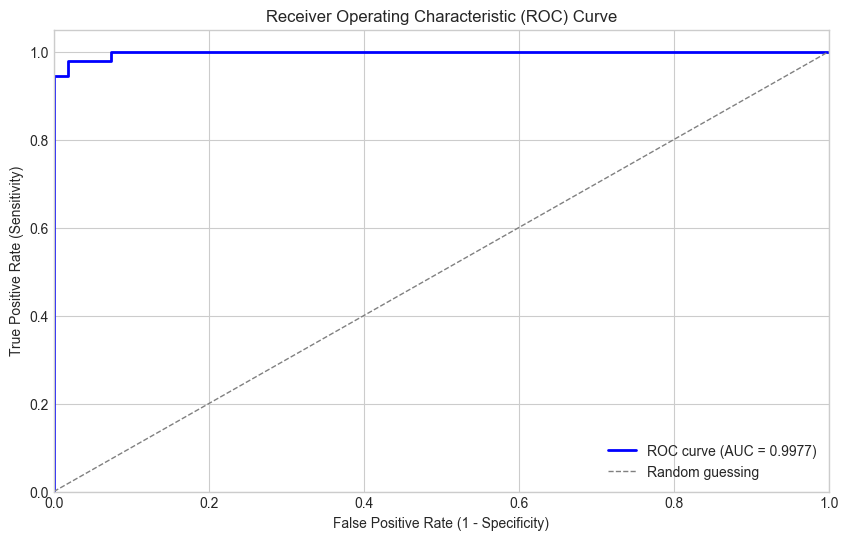

In [12]:
# Get predicted probabilities for ROC curve
y_scores = log_reg.predict_proba(X_test)[:, 1]

# Calculate false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Calculate AUC
roc_auc = roc_auc_score(y_test, y_scores)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Precision-Recall Curve

For imbalanced datasets, the Precision-Recall curve is often more informative than the ROC curve because it focuses on the minority class performance.

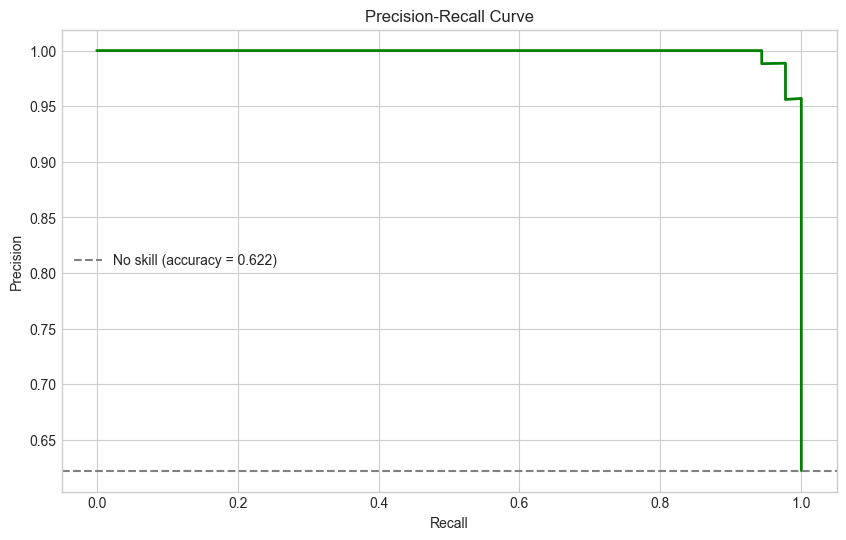

In [13]:
# Calculate precision and recall for different thresholds
precision_values, recall_values, thresholds = precision_recall_curve(y_test, y_scores)

# Plot precision-recall curve
plt.figure(figsize=(10, 6))
plt.plot(recall_values, precision_values, color='green', lw=2)
plt.axhline(y=sum(y_test)/len(y_test), color='gray', linestyle='--', 
           label=f'No skill (accuracy = {sum(y_test)/len(y_test):.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid(True)
plt.show()

## 9. Cross-Validation for Evaluation

To get more reliable estimates of model performance, we can use k-fold cross-validation:

1. Split the data into k equal parts (folds)
2. Train on k-1 folds and test on the remaining fold
3. Repeat k times, each time using a different fold as the test set
4. Average the results to get a more robust estimate of model performance

In [16]:
# # Perform 5-fold cross-validation
# cv = KFold(n_splits=5, shuffle=True, random_state=42)

# # Evaluate using cross-validation
# cv_accuracy = cross_val_score(log_reg, X, y, cv=cv, scoring='accuracy')
# cv_precision = cross_val_score(log_reg, X, y, cv=cv, scoring='precision')
# cv_recall = cross_val_score(log_reg, X, y, cv=cv, scoring='recall')
# cv_f1 = cross_val_score(log_reg, X, y, cv=cv, scoring='f1')
# cv_roc_auc = cross_val_score(log_reg, X, y, cv=cv, scoring='roc_auc')

# # Print cross-validation results
# print("Cross-validation metrics:")
# print(f"Accuracy: {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
# print(f"Precision: {cv_precision.mean():.4f} ± {cv_precision.std():.4f}")
# print(f"Recall: {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
# print(f"F1-Score: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
# print(f"ROC AUC: {cv_roc_auc.mean():.4f} ± {cv_roc_auc.std():.4f}")

# # Visualize cross-validation results
# metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
# mean_scores = [cv_accuracy.mean(), cv_precision.mean(), cv_recall.mean(), cv_f1.mean(), cv_roc_auc.mean()]
# std_scores = [cv_accuracy.std(), cv_precision.std(), cv_recall.std(), cv_f1.std(), cv_roc_auc.std()]

# plt.figure(figsize=(12, 6))
# plt.bar(metrics, mean_scores, yerr=std_scores, capsize=10, alpha=0.7)
# plt.ylim(0.8, 1.0)  # Adjust as needed
# plt.title('Cross-Validation Performance Metrics')
# plt.ylabel('Score')
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.show()

```
ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
```

Cross-validation metrics:
Accuracy:  0.9771 ± 0.0090
Precision: 0.9776 ± 0.0142
Recall:    0.9862 ± 0.0082
F1-Score:  0.9818 ± 0.0073
ROC AUC:   0.9948 ± 0.0056


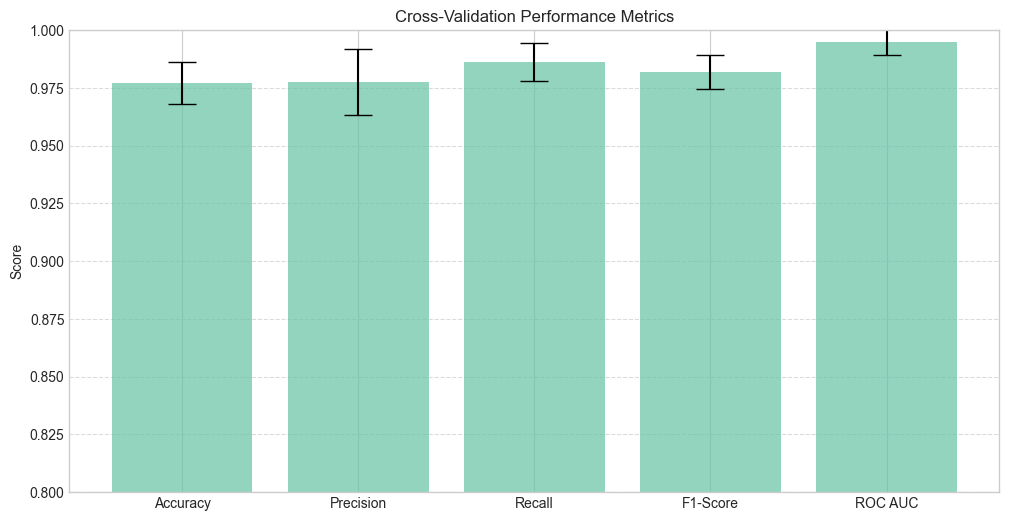

In [15]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

# Create a pipeline with StandardScaler and LogisticRegression
log_reg_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42)
)

# Perform 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate using cross-validation
cv_accuracy = cross_val_score(log_reg_pipeline, X, y, cv=cv, scoring='accuracy')
cv_precision = cross_val_score(log_reg_pipeline, X, y, cv=cv, scoring='precision')
cv_recall = cross_val_score(log_reg_pipeline, X, y, cv=cv, scoring='recall')
cv_f1 = cross_val_score(log_reg_pipeline, X, y, cv=cv, scoring='f1')
cv_roc_auc = cross_val_score(log_reg_pipeline, X, y, cv=cv, scoring='roc_auc')

# Print cross-validation results
print("Cross-validation metrics:")
print(f"Accuracy:  {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
print(f"Precision: {cv_precision.mean():.4f} ± {cv_precision.std():.4f}")
print(f"Recall:    {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"F1-Score:  {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"ROC AUC:   {cv_roc_auc.mean():.4f} ± {cv_roc_auc.std():.4f}")

# Visualize cross-validation results
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
mean_scores = [cv_accuracy.mean(), cv_precision.mean(), cv_recall.mean(), cv_f1.mean(), cv_roc_auc.mean()]
std_scores = [cv_accuracy.std(), cv_precision.std(), cv_recall.std(), cv_f1.std(), cv_roc_auc.std()]

plt.figure(figsize=(12, 6))
plt.bar(metrics, mean_scores, yerr=std_scores, capsize=10, alpha=0.7)
plt.ylim(0.8, 1.0)  # Adjust as needed
plt.title('Cross-Validation Performance Metrics')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 10. Multiple Model Comparison

Let's compare the performance of different classification algorithms on our dataset:
1. Logistic Regression
2. Random Forest
3. Support Vector Machine (SVM)
4. K-Nearest Neighbors (KNN)

In [18]:
# # Initialize models
# models = {
#     'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
#     'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
#     'SVM': SVC(probability=True, random_state=42),
#     'KNN': KNeighborsClassifier(n_neighbors=5)
# }

# # Results dictionary
# results = {}

# # Train and evaluate each model
# for name, model in models.items():
#     print(f"Evaluating {name}...")
    
#     # Perform cross-validation
#     cv_accuracy = cross_val_score(model, X, y, cv=5, scoring='accuracy')
#     cv_precision = cross_val_score(model, X, y, cv=5, scoring='precision')
#     cv_recall = cross_val_score(model, X, y, cv=5, scoring='recall')
#     cv_f1 = cross_val_score(model, X, y, cv=5, scoring='f1')
#     cv_roc_auc = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
    
#     # Store results
#     results[name] = {
#         'accuracy': cv_accuracy.mean(),
#         'precision': cv_precision.mean(),
#         'recall': cv_recall.mean(),
#         'f1': cv_f1.mean(),
#         'roc_auc': cv_roc_auc.mean()
#     }
    
#     print(f"  Accuracy: {cv_accuracy.mean():.4f}")
#     print(f"  ROC AUC: {cv_roc_auc.mean():.4f}")

# # Convert results to DataFrame for easier visualization
# results_df = pd.DataFrame(results).T
# results_df

```
ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
```

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
import pandas as pd

# Initialize models with scaling where needed
models = {
    'Logistic Regression': make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42)
    ),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),  # Tree-based, no scaling needed
    'SVM': make_pipeline(
        StandardScaler(),
        SVC(probability=True, random_state=42)
    ),
    'KNN': make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5)
    )
}

# Results dictionary
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"Evaluating {name}...")
    
    # Perform cross-validation
    cv_accuracy = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    cv_precision = cross_val_score(model, X, y, cv=5, scoring='precision')
    cv_recall = cross_val_score(model, X, y, cv=5, scoring='recall')
    cv_f1 = cross_val_score(model, X, y, cv=5, scoring='f1')
    cv_roc_auc = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
    
    # Store results
    results[name] = {
        'accuracy': cv_accuracy.mean(),
        'precision': cv_precision.mean(),
        'recall': cv_recall.mean(),
        'f1': cv_f1.mean(),
        'roc_auc': cv_roc_auc.mean()
    }
    
    print(f"  Accuracy: {cv_accuracy.mean():.4f}")
    print(f"  ROC AUC: {cv_roc_auc.mean():.4f}")

# Convert results to DataFrame for easier visualization
results_df = pd.DataFrame(results).T
results_df

Evaluating Logistic Regression...
  Accuracy: 0.9807
  ROC AUC: 0.9952
Evaluating Random Forest...
  Accuracy: 0.9561
  ROC AUC: 0.9915
Evaluating SVM...
  Accuracy: 0.9736
  ROC AUC: 0.9959
Evaluating KNN...
  Accuracy: 0.9649
  ROC AUC: 0.9916


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.980686,0.978224,0.991588,0.984767,0.995187
Random Forest,0.956094,0.959039,0.971909,0.965198,0.991491
SVM,0.973638,0.975367,0.983138,0.979113,0.995916
KNN,0.964850,0.962264,0.983099,0.972304,0.991591


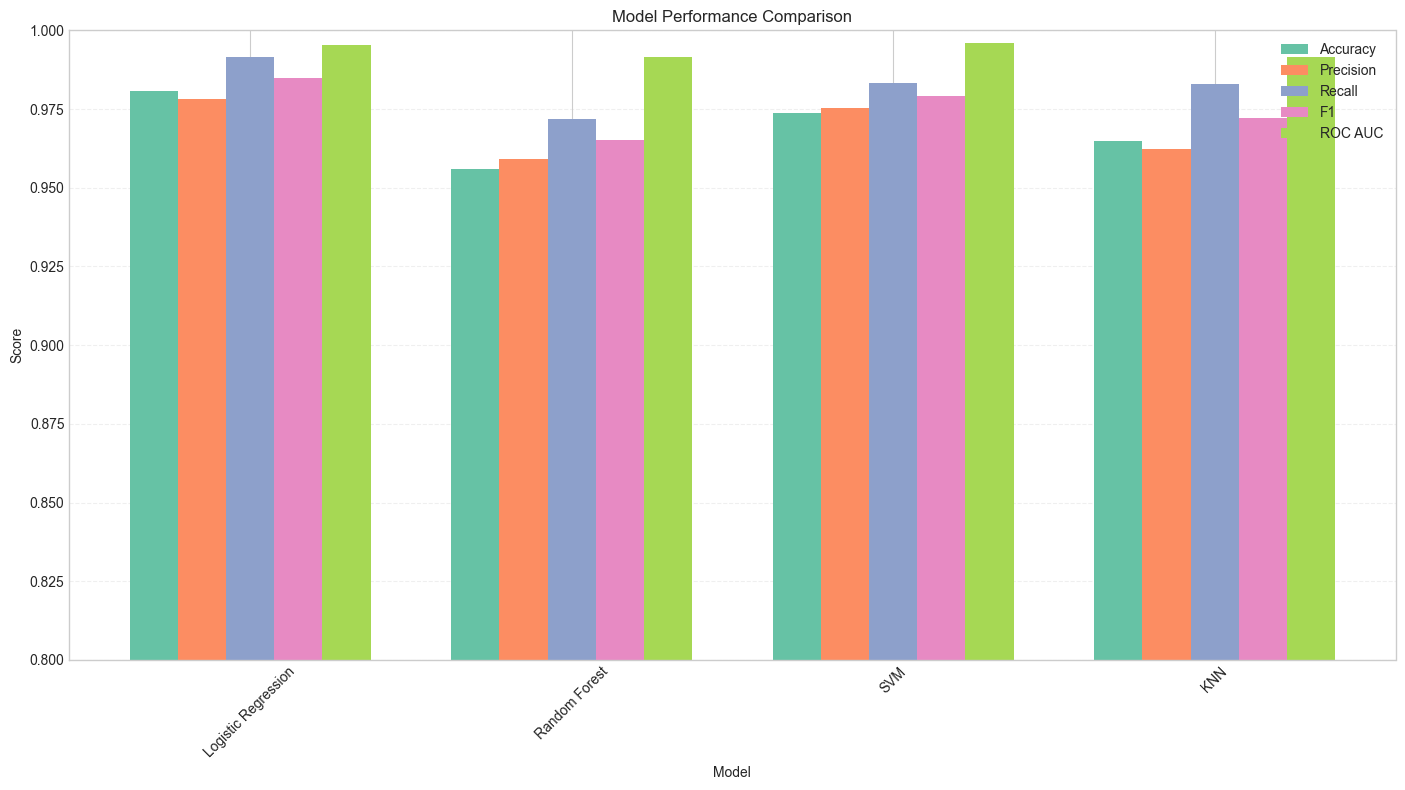

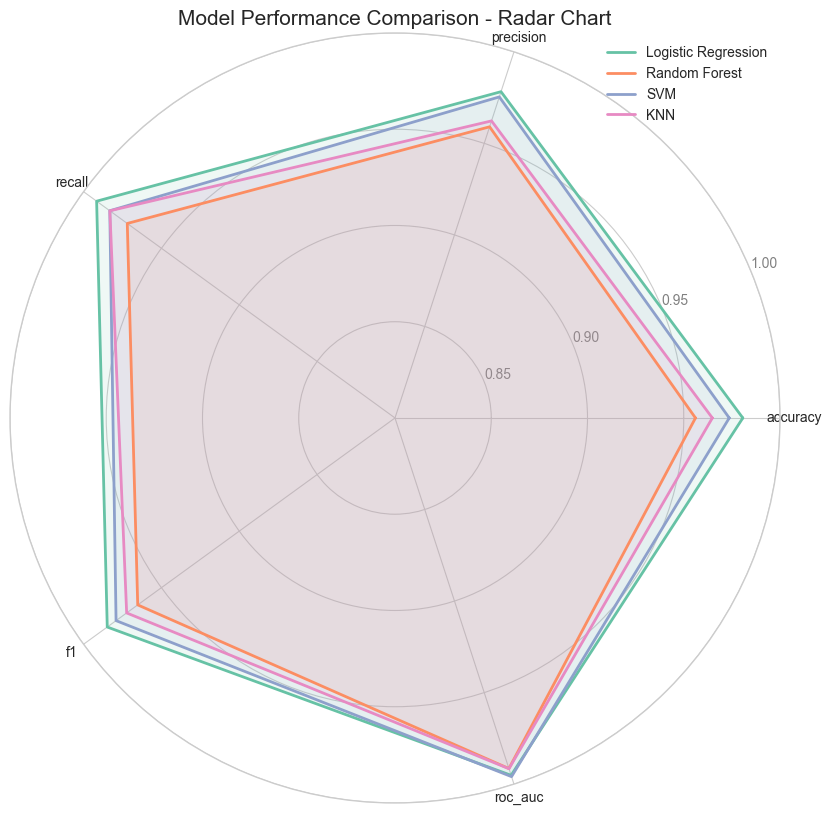

In [20]:
# Create bar chart comparing model performance
plt.figure(figsize=(14, 8))

# Set width of bars
bar_width = 0.15
index = np.arange(len(results_df.index))

# Plot bars for each metric
plt.bar(index - 2*bar_width, results_df['accuracy'], bar_width, label='Accuracy')
plt.bar(index - bar_width, results_df['precision'], bar_width, label='Precision')
plt.bar(index, results_df['recall'], bar_width, label='Recall')
plt.bar(index + bar_width, results_df['f1'], bar_width, label='F1')
plt.bar(index + 2*bar_width, results_df['roc_auc'], bar_width, label='ROC AUC')

# Add labels and title
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(index, results_df.index, rotation=45)
plt.legend()
plt.tight_layout()
plt.ylim(0.8, 1.0)  # Adjust as needed
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# Plot radar chart for model comparison
categories = list(results_df.columns)
n_categories = len(categories)

# Create angles for the radar chart
angles = np.linspace(0, 2*np.pi, n_categories, endpoint=False).tolist()
angles += angles[:1]  # Close the loop

# Set up the figure
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Plot each model
for model_name, model_results in results_df.iterrows():
    values = model_results.tolist()
    values += values[:1]  # Close the loop
    ax.plot(angles, values, linewidth=2, label=model_name)
    ax.fill(angles, values, alpha=0.1)

# Set category labels
plt.xticks(angles[:-1], categories)
plt.yticks([0.85, 0.9, 0.95, 1.0], ['0.85', '0.90', '0.95', '1.00'], color='gray')
plt.ylim(0.8, 1.0)

# Add legend and title
plt.legend(loc='upper right')
plt.title('Model Performance Comparison - Radar Chart', size=15)
plt.show()

## Summary

In this notebook, we've explored fundamental model evaluation techniques for classification problems:

1. **Accuracy**: The most basic metric, but can be misleading for imbalanced datasets
2. **Confusion Matrix**: Provides detailed breakdown of correct and incorrect predictions by class
3. **Precision, Recall, and F1-Score**: Important metrics derived from the confusion matrix
4. **ROC Curve and AUC**: Visualizes and quantifies model performance across thresholds
5. **Cross-Validation**: Provides more robust performance estimates
6. **Model Comparison**: Evaluates different algorithms using multiple metrics

Key takeaways:
- Model evaluation should never rely on a single metric
- The choice of metric depends on the problem context and the costs of different types of errors
- For imbalanced data, precision, recall, and F1-score are more informative than accuracy
- Cross-validation provides more reliable performance estimates than a single train-test split
- Different models may excel at different evaluation metrics

These evaluation techniques form the foundation for selecting the best model for a given classification task and understanding its strengths and limitations.